In [1]:
import pickle, numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (f1_score, roc_auc_score,
    average_precision_score, classification_report)
import matplotlib.pyplot as plt

with open('../preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train_normal'].values.astype(np.float32)
X_test  = data['X_test'].values.astype(np.float32)
y_test  = data['y_test']
IN_DIM  = X_train.shape[1]
device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device} | Input dim: {IN_DIM}')

Using device: cpu | Input dim: 16


In [2]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, 8),         nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),         nn.ReLU(),
            nn.Linear(32, 64),        nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae = Autoencoder(IN_DIM).to(device)
print(f'AE parameters: {sum(p.numel() for p in ae.parameters()):,}')

AE parameters: 6,872


Training Autoencoder on Normal data only...


  Epoch  20/100  Loss: 0.367580


  Epoch  40/100  Loss: 0.311494


  Epoch  60/100  Loss: 0.265081


  Epoch  80/100  Loss: 0.214471


  Epoch 100/100  Loss: 0.196060


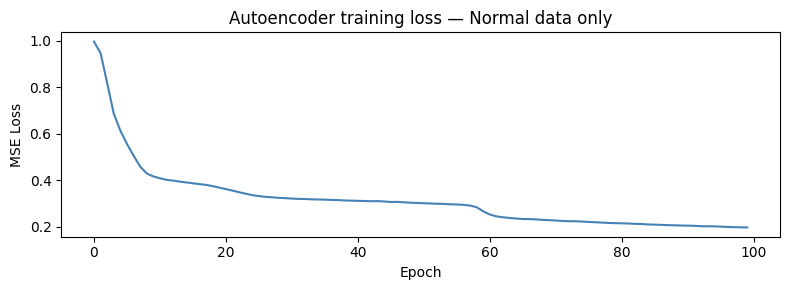

In [3]:
Xt      = torch.FloatTensor(X_train).to(device)
loader  = DataLoader(TensorDataset(Xt, Xt), batch_size=256, shuffle=True)
opt     = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

print('Training Autoencoder on Normal data only...')
losses = []
for epoch in range(100):
    ae.train()
    ep_loss = 0
    for xb, _ in loader:
        recon = ae(xb)
        loss  = loss_fn(recon, xb)
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item()
    losses.append(ep_loss / len(loader))
    if (epoch + 1) % 20 == 0:
        print(f'  Epoch {epoch+1:>3}/100  Loss: {losses[-1]:.6f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Autoencoder training loss — Normal data only')
plt.tight_layout()
plt.savefig('../outputs/ae_loss.png', dpi=150)
plt.show()

In [4]:
def get_errors(model, X_np):
    model.eval()
    with torch.no_grad():
        Xt = torch.FloatTensor(X_np).to(device)
        r  = model(Xt)
        return ((Xt - r)**2).mean(dim=1).cpu().numpy()

train_errors = get_errors(ae, X_train)
test_errors  = get_errors(ae, X_test)
threshold    = np.percentile(train_errors, 95)
ae_preds     = (test_errors > threshold).astype(int)

print(f'\nThreshold (95th pct of Normal errors): {threshold:.6f}')
print('\n=== Autoencoder Results ===')
print(classification_report(y_test, ae_preds,
      target_names=['Normal', 'Anomaly'], digits=4))
print(f'AUC-ROC: {roc_auc_score(y_test, test_errors):.4f}')
print(f'AUC-PR:  {average_precision_score(y_test, test_errors):.4f}')


Threshold (95th pct of Normal errors): 0.438920

=== Autoencoder Results ===
              precision    recall  f1-score   support

      Normal     0.4361    0.9289    0.5935      1590
     Anomaly     0.5569    0.0692    0.1231      2052

    accuracy                         0.4445      3642
   macro avg     0.4965    0.4991    0.3583      3642
weighted avg     0.5041    0.4445    0.3285      3642

AUC-ROC: 0.5144
AUC-PR:  0.5707


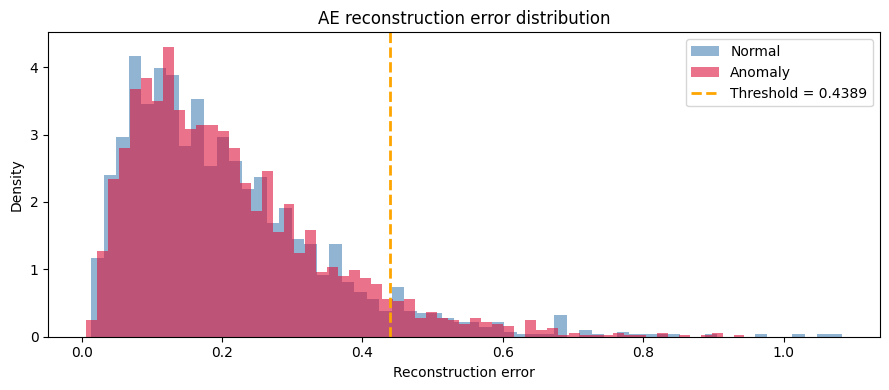

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_errors[y_test==0], bins=60, alpha=0.6, label='Normal',
        color='steelblue', density=True)
ax.hist(test_errors[y_test==1], bins=60, alpha=0.6, label='Anomaly',
        color='crimson', density=True)
ax.axvline(threshold, color='orange', linestyle='--', linewidth=2,
           label=f'Threshold = {threshold:.4f}')
ax.set_xlabel('Reconstruction error'); ax.set_ylabel('Density')
ax.set_title('AE reconstruction error distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/ae_error_distribution.png', dpi=150)
plt.show()

In [6]:
data['ae_model']     = ae
data['ae_scores']    = test_errors
data['ae_preds']     = ae_preds
data['ae_threshold'] = threshold
with open('../preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data, f)
print('Saved. Run notebook 4 next.')

Saved. Run notebook 4 next.
